In [2]:
import networkx as nx
import pandas as pd
import numpy as np
from auxiliary_functions import *
from collections import defaultdict
import matplotlib.pyplot as plt

In [ ]:
from tqdm.notebook import tqdm

In [3]:
graph = nx.read_gexf("labeled_graph.gexf")
threshold = 0.5
NumberOfRandoms = 100

In [4]:
graphs = defaultdict(nx.MultiDiGraph)

for a, b, data in graph.edges(data=True):
	graphs[data["subreddit"]].add_edge(a, b, weight=data["weight"])

for subreddit, graph in graphs.items():
	diction = defaultdict(lambda: defaultdict(list))
	for a, b, data in graph.edges(data=True):
		diction[a][b].append(data["weight"])
	new_graph = nx.Graph()
	for node in diction.keys():
		for neighbor in diction[node].keys():
			if node == neighbor:
				continue
			weights = np.array(diction[node][neighbor] + (diction[neighbor][node] if neighbor in diction and node in diction[neighbor] else []))
			if weights.std() >= threshold:
				continue
			mean = np.mean(weights)
			if mean == 0:
				continue
			new_graph.add_edge(node, neighbor, weight=mean)
	graphs[subreddit] = new_graph

null_models = {}
for subreddit, graph in graphs.items():
	null_models[subreddit] = [generate_null_model(graph) for _ in range(NumberOfRandoms)]

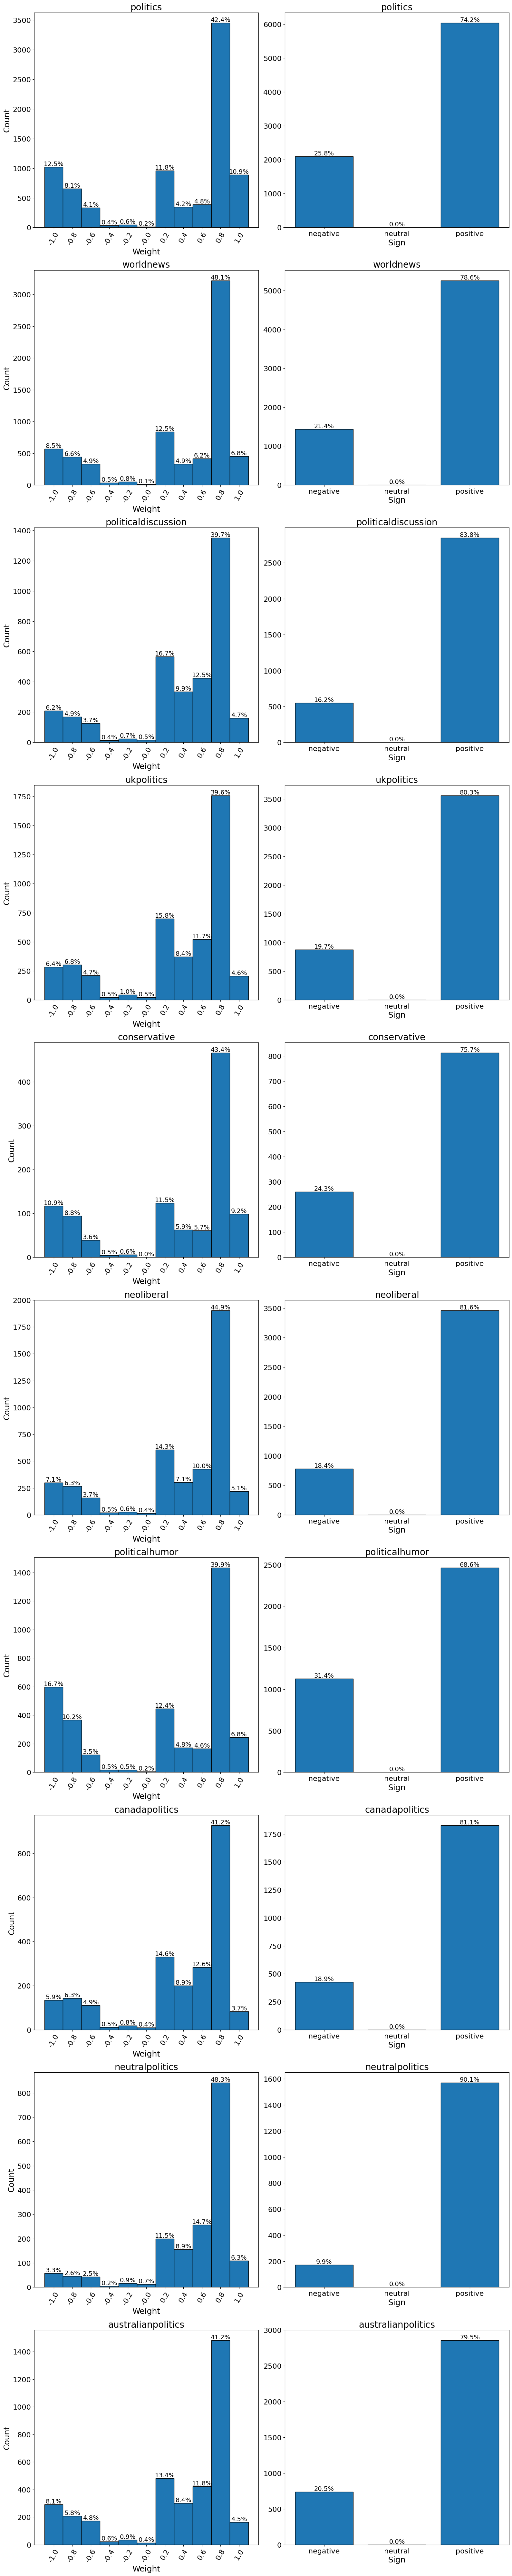

In [ ]:
fig, axes = plt.subplots(len(graphs), 2, figsize=(16, 8 * len(graphs)))

centers = np.arange(-1, 1.1, 0.2)
edges = centers - .1
edges = np.append(edges, edges[-1] + 0.2)  # add rightmost edge

for ind, subreddit in enumerate(graphs):
    axes[ind][0].set_title(subreddit, fontsize=20)
    axes[ind][1].set_title(subreddit, fontsize=20)
    w = np.array([data["weight"] for a, b, data in graphs[subreddit].edges(data=True)])
    
    # Histogram for weights
    counts, bins, patches = axes[ind][0].hist(w, bins=edges, edgecolor="black")
    axes[ind][0].set_xticks(centers)
    axes[ind][0].set_xticklabels([f"{x:.1f}" for x in centers], rotation=60)
    total = counts.sum()
    for count, bin_left, bin_right in zip(counts, bins[:-1], bins[1:]):
        percent = 100 * count / total if total > 0 else 0
        xpos = (bin_left + bin_right) / 2
        axes[ind][0].text(xpos, count, f"{percent:.1f}%", ha='center', va='bottom', fontsize=14)
    
    # Histogram for sign
    sign_bins = [-1.5, -0.5, 0.5, 1.5]
    sign_labels = ["negative", "neutral", "positive"]
    sign_counts, sign_bins, sign_patches = axes[ind][1].hist(np.sign(w), edgecolor="black", bins=sign_bins, rwidth=0.8)
    axes[ind][1].set_xticks([-1, 0, 1])
    axes[ind][1].set_xticklabels(sign_labels, fontsize=16)
    sign_total = sign_counts.sum()
    for count, bin_left, bin_right in zip(sign_counts, sign_bins[:-1], sign_bins[1:]):
        percent = 100 * count / sign_total if sign_total > 0 else 0
        xpos = (bin_left + bin_right) / 2
        axes[ind][1].text(xpos, count, f"{percent:.1f}%", ha='center', va='bottom', fontsize=14)
    
    axes[ind][0].tick_params(axis='both', labelsize=16)
    axes[ind][1].tick_params(axis='both', labelsize=16)
    axes[ind][0].set_xlabel("Weight", fontsize=18)
    axes[ind][1].set_xlabel("Sign", fontsize=18)
    axes[ind][0].set_ylabel("Count", fontsize=18)



plt.tight_layout()
plt.show()

In [5]:
triangles = {}

for subreddit in graphs.keys():
	triangles[subreddit] = set()
	graph = graphs[subreddit]
	for node1 in graph.nodes:
		for node2 in graph.neighbors(node1):
			for node3 in graph.neighbors(node2):
				if (graph.has_edge(node1, node3)):
					triangles[subreddit].add(tuple(sorted([node1, node2, node3])))

for subreddit, triangles_set in triangles.items():
    numerical_triangles = []
    for triangle in triangles_set:
        node1 = triangle[0]
        node2 = triangle[1]
        node3 = triangle[2]
        weight1 = graphs[subreddit][node1][node2]["weight"]
        weight2 = graphs[subreddit][node1][node3]["weight"]
        weight3 = graphs[subreddit][node2][node3]["weight"]
        numerical_triangles.append((weight1, weight2, weight3))
    triangles[subreddit] = numerical_triangles

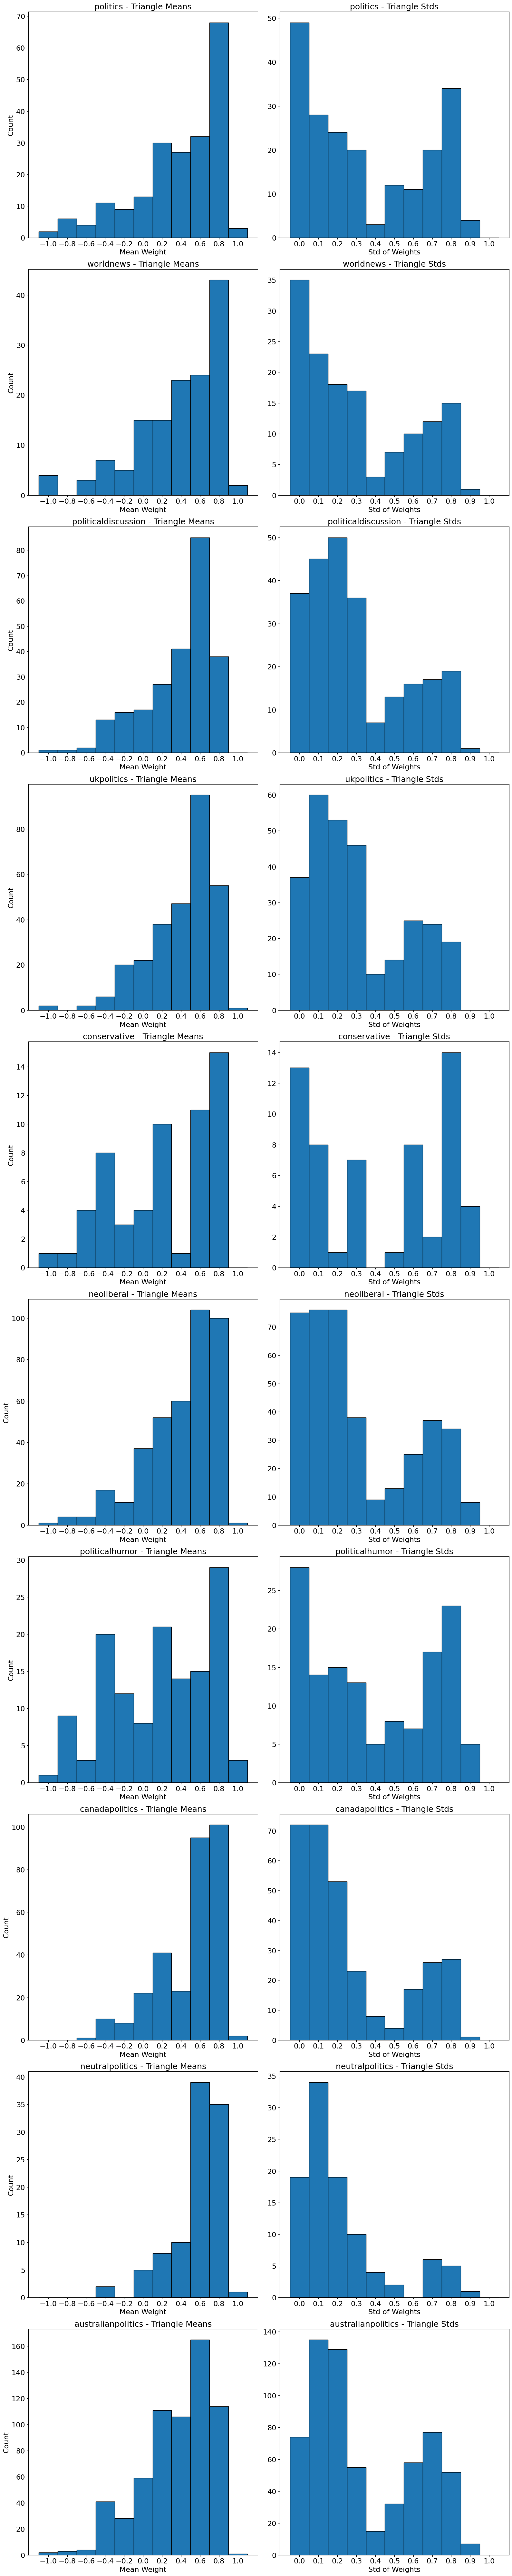

In [ ]:
fig, axes = plt.subplots(len(graphs), 2, figsize=(16, 8 * len(graphs)))

for i, (subreddit, triangles_list) in enumerate(triangles.items()):
	means = []
	stds = []
	for triangle in triangles_list:
		means.append(np.mean(triangle))
		stds.append(np.std(triangle))
	
	# Plot histogram of means
	axes[i][0].hist(means, bins=edges, edgecolor="black")
	axes[i][0].set_xticks(centers)
	axes[i][0].set_title(f"{subreddit} - Triangle Means", fontsize=18)
	axes[i][0].set_xlabel("Mean Weight", fontsize=16)
	axes[i][0].set_ylabel("Count", fontsize=16)
	axes[i][0].tick_params(axis='both', labelsize=16)

	# Plot histogram of stds
	std_bins = np.arange(-0.05, 1.11, 0.1)
	std_centers = np.arange(0, 1.1, 0.1)

	axes[i][1].hist(stds, bins=std_bins, edgecolor="black")
	axes[i][1].set_xticks(std_centers)
	axes[i][1].set_title(f"{subreddit} - Triangle Stds", fontsize=18)
	axes[i][1].set_xlabel("Std of Weights", fontsize=16)
	axes[i][1].tick_params(axis='both', labelsize=16)

	
plt.tight_layout()
plt.show()

In [6]:
series_dict = {}

for subreddit in graphs.keys():
	qnt_pos = [0 for i in range(4)]

	for triangle in triangles[subreddit]:
		qnt_pos[list(np.sign(triangle)).count(1)] += 1

	qnt_pos_series = pd.Series(qnt_pos, name=subreddit)
	series_dict[subreddit] = qnt_pos_series

# Create DataFrame from the series
df = pd.DataFrame(series_dict).T
df.columns = ['0 pos edges', '1 pos edge', '2 pos edges', '3 pos edges']
df.to_csv('file.csv', index=True)
df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
politics,9,21,62,113
worldnews,6,10,40,85
politicaldiscussion,3,24,48,166
ukpolitics,3,24,67,194
conservative,2,14,15,27
neoliberal,6,29,100,256
politicalhumor,11,30,36,58
canadapolitics,0,16,68,219
neutralpolitics,0,3,15,82
australianpolitics,9,64,184,377


In [ ]:
results = {}
for subreddit, graph in tqdm(graphs.items()):
    simplified_original_graph = absolute_graph(graph)
    simplified_null_model = [absolute_graph(null_models[subreddit][i]) for i in range(NumberOfRandoms)]
    # nu_s = calculate_bs(simplified_original_graph) / calculate_bs(simplified_null_model)
    nu_w = calculate_bw(simplified_original_graph)
    standard = [calculate_bw(simplified_null_model[i]) for _ in range(NumberOfRandoms)]
    standard = sum(standard) / NumberOfRandoms
    # results[subreddit] = {'nu_s': nu_s, 'nu_w': nu_w}
    results[subreddit] = {'B_w': nu_w, "Standard_B_w": standard, "nu_w" : nu_w / standard}

df_nu = pd.DataFrame.from_dict(results, orient='index')
df_nu

KeyboardInterrupt: 

In [7]:
def geo_abs(triangle: list):
    return (abs(triangle[0]) * abs(triangle[1]) * abs(triangle[2])) ** (1 / 3)

def in_balance(triangle: list):
    triangle = list(np.sign(np.array(triangle)))
    for el in triangle:
        assert(el)
    
    return 1 - (triangle.count(-1) % 2)

In [23]:
# Calculate triangles for null models
null_triangles = {}

for subreddit in graphs.keys():
	null_triangles[subreddit] = []
	
	for null_graph in null_models[subreddit]:
		triangles_set = set()
		for node1 in null_graph.nodes:
			for node2 in null_graph.neighbors(node1):
				for node3 in null_graph.neighbors(node2):
					if null_graph.has_edge(node1, node3):
						triangles_set.add(tuple(sorted([node1, node2, node3])))
		
		numerical_triangles = []
		for triangle in triangles_set:
			node1, node2, node3 = triangle[0], triangle[1], triangle[2]
			weight1 = null_graph[node1][node2]["weight"]
			weight2 = null_graph[node1][node3]["weight"]
			weight3 = null_graph[node2][node3]["weight"]
			numerical_triangles.append((weight1, weight2, weight3))
		
		null_triangles[subreddit].append(numerical_triangles)

print(f"Calculated triangles for {len(null_triangles)} subreddits with {NumberOfRandoms} null models each")


Calculated triangles for 10 subreddits with 100 null models each


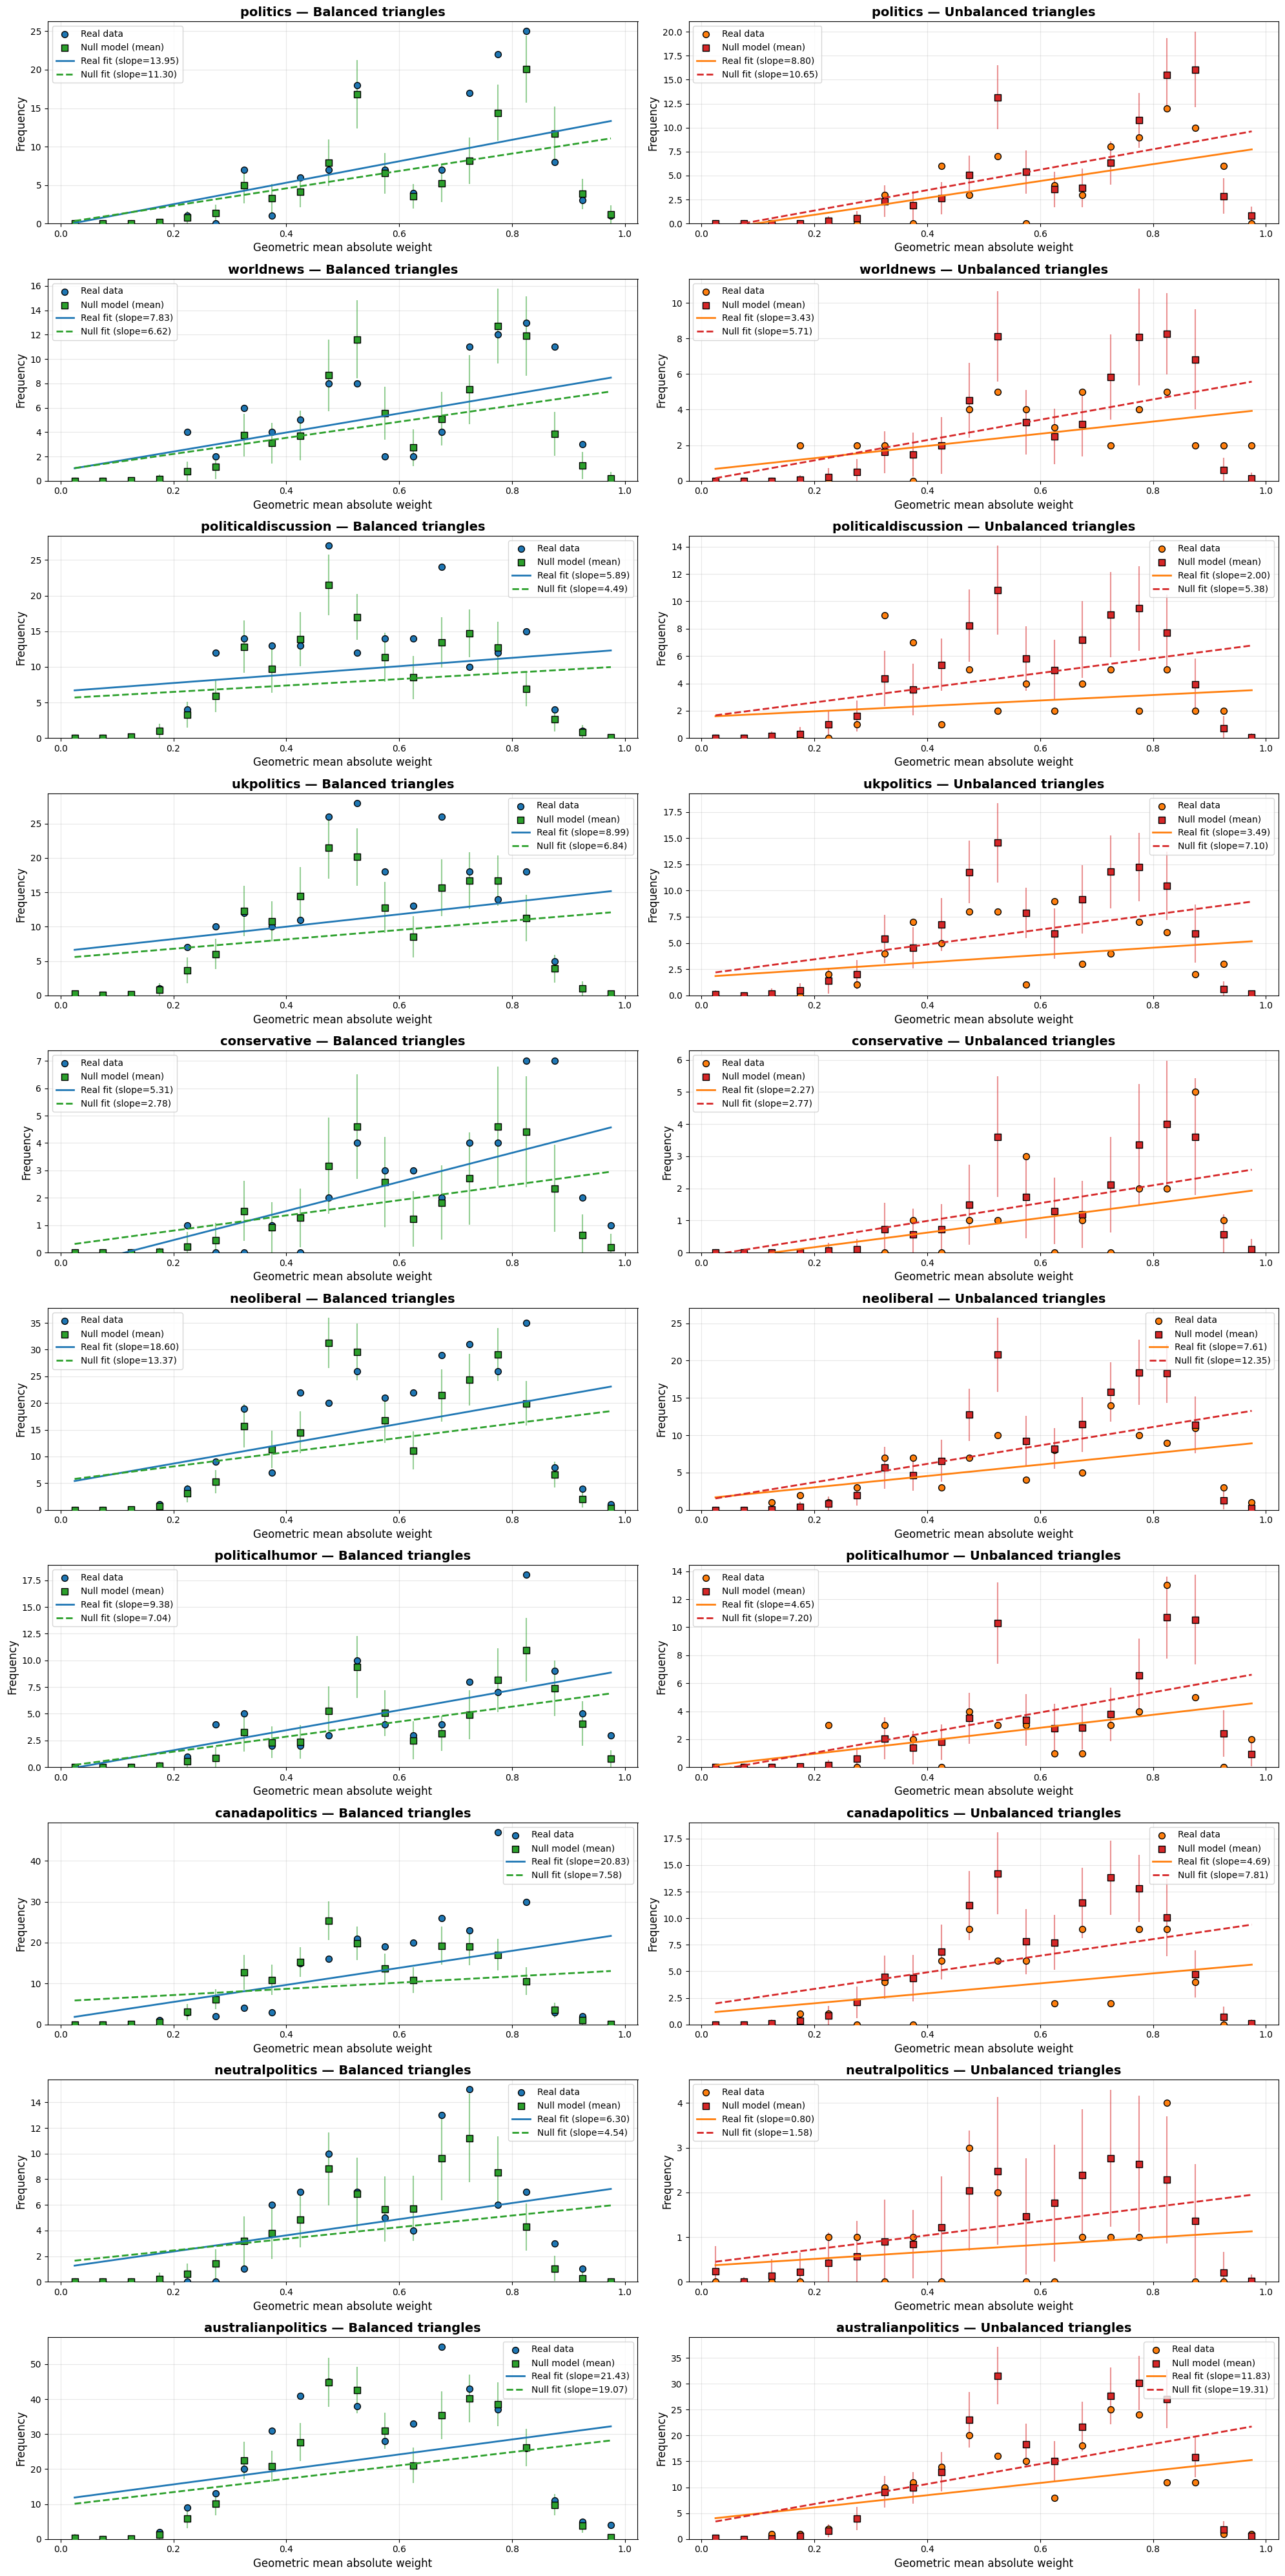

In [24]:
fig, axes = plt.subplots(len(graphs), 2, figsize=(20, 4 * len(graphs)))
if len(graphs) == 1:
	axes = axes.reshape(1, -1)

bins = np.linspace(0, 1, 21)
bin_centers = (bins[:-1] + bins[1:]) / 2

for ind, (subreddit, numerical_triangles) in enumerate(triangles.items()):
	# Real data
	geo_balanced = []
	geo_unbalanced = []
	for triangle in numerical_triangles:
		if in_balance(triangle):
			geo_balanced.append(geo_abs(triangle))
		else:
			geo_unbalanced.append(geo_abs(triangle))

	counts_bal_real, _ = np.histogram(geo_balanced, bins=bins)
	counts_unbal_real, _ = np.histogram(geo_unbalanced, bins=bins)

	# Null models data
	null_counts_bal_list = []
	null_counts_unbal_list = []
	
	for null_tri in null_triangles[subreddit]:
		geo_balanced_null = []
		geo_unbalanced_null = []
		for triangle in null_tri:
			if in_balance(triangle):
				geo_balanced_null.append(geo_abs(triangle))
			else:
				geo_unbalanced_null.append(geo_abs(triangle))
		
		counts_bal_null, _ = np.histogram(geo_balanced_null, bins=bins)
		counts_unbal_null, _ = np.histogram(geo_unbalanced_null, bins=bins)
		null_counts_bal_list.append(counts_bal_null)
		null_counts_unbal_list.append(counts_unbal_null)
	
	# Calculate mean and std for null models
	null_counts_bal_mean = np.mean(null_counts_bal_list, axis=0)
	null_counts_bal_std = np.std(null_counts_bal_list, axis=0)
	null_counts_unbal_mean = np.mean(null_counts_unbal_list, axis=0)
	null_counts_unbal_std = np.std(null_counts_unbal_list, axis=0)

	# Plot balanced triangles
	ax_bal = axes[ind][0]
	ax_bal.scatter(bin_centers, counts_bal_real, color='C0', s=50, edgecolor='k', marker='o', zorder=5, label='Real data')
	ax_bal.scatter(bin_centers, null_counts_bal_mean, color='C2', s=50, edgecolor='k', marker='s', zorder=5, label='Null model (mean)')
	ax_bal.errorbar(bin_centers, null_counts_bal_mean, yerr=null_counts_bal_std, fmt='none', ecolor='C2', alpha=0.5, zorder=4)
	
	# Fit lines for balanced
	if counts_bal_real.sum() > 0 and np.count_nonzero(counts_bal_real) > 1:
		slope, intercept = np.polyfit(bin_centers, counts_bal_real, 1)
		y_fit = slope * bin_centers + intercept
		ax_bal.plot(bin_centers, y_fit, color='C0', linewidth=2, zorder=10, label=f'Real fit (slope={slope:.2f})')
	
	if null_counts_bal_mean.sum() > 0 and np.count_nonzero(null_counts_bal_mean) > 1:
		slope_null, intercept_null = np.polyfit(bin_centers, null_counts_bal_mean, 1)
		y_fit_null = slope_null * bin_centers + intercept_null
		ax_bal.plot(bin_centers, y_fit_null, color='C2', linewidth=2, linestyle='--', zorder=10, label=f'Null fit (slope={slope_null:.2f})')
	
	ax_bal.set_title(f'{subreddit} — Balanced triangles', fontsize=14, fontweight='bold')
	ax_bal.set_xlabel('Geometric mean absolute weight', fontsize=12)
	ax_bal.set_ylabel('Frequency', fontsize=12)
	ax_bal.legend(fontsize=10)
	ax_bal.tick_params(axis='both', labelsize=10)
	ax_bal.set_ylim(bottom=0)
	ax_bal.grid(alpha=0.3)

	# Plot unbalanced triangles
	ax_unbal = axes[ind][1]
	ax_unbal.scatter(bin_centers, counts_unbal_real, color='C1', s=50, edgecolor='k', marker='o', zorder=5, label='Real data')
	ax_unbal.scatter(bin_centers, null_counts_unbal_mean, color='C3', s=50, edgecolor='k', marker='s', zorder=5, label='Null model (mean)')
	ax_unbal.errorbar(bin_centers, null_counts_unbal_mean, yerr=null_counts_unbal_std, fmt='none', ecolor='C3', alpha=0.5, zorder=4)
	
	# Fit lines for unbalanced
	if counts_unbal_real.sum() > 0 and np.count_nonzero(counts_unbal_real) > 1:
		slope, intercept = np.polyfit(bin_centers, counts_unbal_real, 1)
		y_fit = slope * bin_centers + intercept
		ax_unbal.plot(bin_centers, y_fit, color='C1', linewidth=2, zorder=10, label=f'Real fit (slope={slope:.2f})')
	
	if null_counts_unbal_mean.sum() > 0 and np.count_nonzero(null_counts_unbal_mean) > 1:
		slope_null, intercept_null = np.polyfit(bin_centers, null_counts_unbal_mean, 1)
		y_fit_null = slope_null * bin_centers + intercept_null
		ax_unbal.plot(bin_centers, y_fit_null, color='C3', linewidth=2, linestyle='--', zorder=10, label=f'Null fit (slope={slope_null:.2f})')
	
	ax_unbal.set_title(f'{subreddit} — Unbalanced triangles', fontsize=14, fontweight='bold')
	ax_unbal.set_xlabel('Geometric mean absolute weight', fontsize=12)
	ax_unbal.set_ylabel('Frequency', fontsize=12)
	ax_unbal.legend(fontsize=10)
	ax_unbal.tick_params(axis='both', labelsize=10)
	ax_unbal.set_ylim(bottom=0)
	ax_unbal.grid(alpha=0.3)

plt.tight_layout()
plt.show()
